<a href="https://colab.research.google.com/github/SheethHassan/AI-Based-Pneumonia-Detection/blob/ML-MODEL/Pneumonia_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#PYTHON LIBRARIES

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, callbacks, applications, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score)

In [2]:
# LOADING DATASET
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Verfing Folder Structure

import os
for split in ['train', 'val', 'test']:
  for cls in ['NORMAL', 'PNEUMONIA']:
    path = f'/content/drive/MyDrive/chest_xray/chest_xray/{split}/{cls}'
    count = len(os.listdir(path))
    print(f"{split}/{cls}:{count} images")

train/NORMAL:1342 images
train/PNEUMONIA:3876 images
val/NORMAL:9 images
val/PNEUMONIA:9 images
test/NORMAL:234 images
test/PNEUMONIA:390 images


In [5]:
#Constants

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
INPUT_SHAPE = (224,224,3)
SEED = 42

In [6]:

base_dir = '/content/drive/MyDrive/chest_xray/chest_xray'
train_dir = f'{base_dir}/train'
test_dir = f'{base_dir}/test'

#PREPROCESSING & AUGMENTATION
#AUGMENTATION ONLY FOR TRAINING DATA
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.15,
    zoom_range = 0.2,
    horizontal_flip = True,
    brightness_range = [0.8, 1.2],
    fill_mode = "nearest",
    validation_split = 0.20 #validation split
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'binary',
    seed = SEED,
    shuffle = True,
    subset = 'training'
)
val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "binary",
    seed = SEED,
    subset = "validation"

)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "binary",
    shuffle = False
)

print(f"Training Images: {train_gen.samples}")
print(f"validation Images:{val_gen.samples}")
print(f"Test Images: {test_gen.samples}")
print(f"Class indicies: {train_gen.class_indices}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Training Images: 4173
validation Images:1043
Test Images: 624
Class indicies: {'NORMAL': 0, 'PNEUMONIA': 1}


In [7]:
#CLASS IMBALANCE
#Since the dataset has 1341 images train/NORMAL and 3875 images train/PNEUMONIA during traing without correction the model learns a bad habit which is guessing pneumonia 3x than guessing normal images which is called
# a biased model since it will miss real normal cases.
# This is fixed by using class imabalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.array([0,1]),
    y = train_gen.classes
)
class_weight_dict = {0:class_weights[0], 1:class_weights[1]}

print(f"Class weight for NORMAL is: {class_weight_dict[0]:.4f}")
print(f"Class weight for PNEUMONIA is : {class_weight_dict[1]:.4f}")

Class weight for NORMAL is: 1.9445
Class weight for PNEUMONIA is : 0.6731


In [8]:
#PHASE 1 - MOBILENETv2 MODEL
#Load Mobilenetv2 pretrained on ImageNet
base_model = MobileNetV2(
    input_shape = INPUT_SHAPE,
    include_top = False, #Remove Imagenet classification head
    weights = "imagenet" #use pretrained weights
)

#Freeze Model

base_model.trainable = False


#Main Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid') #Binary output either PNEUMONIA OR NOT
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# MODEL COMPILE

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001),
    loss = 'binary_crossentropy',
    metrics = [
        'accuracy',
        tf.keras.metrics.AUC(name = 'auc'),
        tf.keras.metrics.Precision(name = 'precision'),
        tf.keras.metrics.Recall(name = 'recall')
    ]
)
model.summary()

In [ ]:
#Callbacks
callbacks = [
    #stop learning if val_loss doesn't improve in 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True,
        verbose = 1
    ),

    #reduce learning rate if val_loss plateaus for 3 epochs
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 3,
        verbose = 1,
        min_lr = 0.0000001
    ),
    #save the best model automatically
    tf.keras.callbacks.ModelCheckpoint(
        filepath = '/content/drive/MyDrive/best_model_phase1.h5',
        monitor = 'val_auc',
        save_best_only = True,
        verbose = 1
    )
]

#Phase 1 -- Custom Top Layer Training
print("=" * 50)
print("Phase 1: Training Top layers of the model only")
print(f"Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print("=" * 50)

history_phase1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = 20,
    class_weight = class_weight_dict,
    callbacks = callbacks
)

In [ ]:
#PHASE 2 - Fine Tuning the Model
# Unfreeze Stage of top layers and training the rest of the model

print("=" * 50)
print("PHASE 2: Fine Tuning")
print("=" * 50)

#Unfreezing Model
base_model.trainable = True

#Freeze all layers except last 30 layers
for layer in base_model.layers[:-30]:
  layer.trainable = False


#Check how many layres are now trainable
trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Trainable layers: {trainable_layers}")

#Recompile with a much lower rate to increase accuracy a bit higher
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.00001),
    loss = 'binary_crossentropy',
    metrics = [
        'accuracy',
        tf.keras.metrics.AUC(name = 'auc'),
        tf.keras.metrics.Precision(name = 'precision'),
        tf.keras.metrics.Recall(name = 'recall')
    ]
)

#update callbacks for phase 2
callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True,
        verbose = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 3,
        verbose = 1,
        min_lr = 0.0000001
    ),
    #Save best model in google drive
    tf.keras.callbacks.ModelCheckpoint(
        filepath = '/content/drive/MyDrive/best_model_phase2.h5',
        monitor = 'val_auc',
        save_best_only = True,
        verbose = 1
    )
]

#Train Second Phase
history_phase2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = 20,
    class_weight = class_weight_dict,
    callbacks = callbacks_phase2
)


In [ ]:
model.save('/content/drive/MyDrive/pneumonia_final_model.h5')
print("Model saved successfully — safe to go!")

In [9]:
model = tf.keras.models.load_model('/content/drive/MyDrive/pneumonia_final_model.h5')

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
    loss = 'binary_crossentropy',
    metrics = [
        'accuracy',
        tf.keras.metrics.AUC(name = 'auc'),
        tf.keras.metrics.Precision(name = 'precision'),
        tf.keras.metrics.Recall(name = 'recall')
    ]
)
print("Model Loaded and compiled sucessfully")

Model Loaded


In [10]:
results = model.evaluate(val_gen, verbose = 1)
print(f"nAccuracy: {results[1]*100:.2f}%")
print(f"nAuc: {results[2]:.4f}")
print(f"Recall : {results[4]*100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 324s 9s/step - accuracy: 0.9108 - auc: 0.9726 - loss: 0.2385 - precision: 0.9021 - recall: 0.9871
nAccuracy: 91.08%
nAuc: 0.9726
Recall : 98.71%


In [11]:
#Reset  test generator before predicting
test_gen.reset()

print("=" * 50)
print("FINAL EVALUATION ON TEST SET")
print("=" * 50)

test_results = model.evaluate(test_gen, verbose = 1)
print(f"\nTest Set Results")
print(f"Loss: {test_results[0]:.4f}")
print(f"\nAuccuracy: {test_results[1]* 100:.2f}%")
print(f"\nAUC: {test_results[2]:.4f}")
print(f"Precision: {test_results[3]*100:.2f}%")
print(f"Recall: {test_results[4]*100:.2f}%")

FINAL EVALUATION ON TEEST SET
20/20 ━━━━━━━━━━━━━━━━━━━━ 191s 10s/step - accuracy: 0.8413 - auc: 0.9299 - loss: 0.6488 - precision: 0.8000 - recall: 0.9949

Test Set Resutls
Loss: 0.6488
Auccuracy: 84.13%
AUC: 0.9299
Precision: 80.00%
Recall: 99.49%


20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step


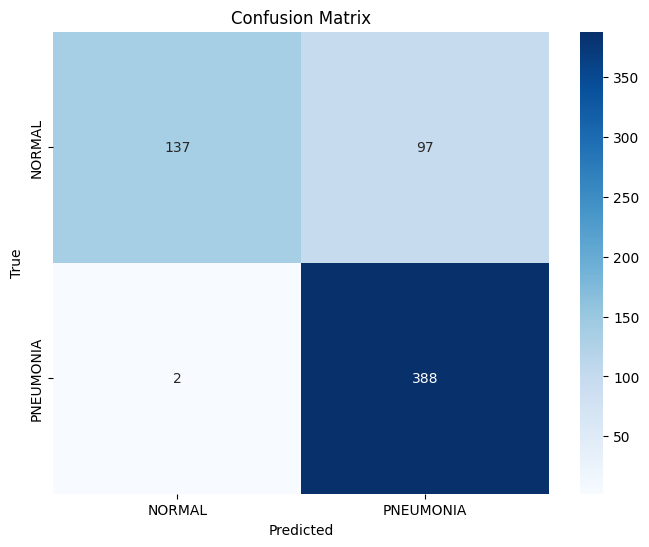


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.59      0.73       234
   PNEUMONIA       0.80      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624

True Negatives  — NORMAL correctly identified:     137
False Positives — NORMAL wrongly called PNEUMONIA: 97
False Negatives — PNEUMONIA missed:                2
True Positives  — PNEUMONIA correctly identified:  388


In [12]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred, target_names=CLASS_NAMES
))


tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  — NORMAL correctly identified:     {tn}")
print(f"False Positives — NORMAL wrongly called PNEUMONIA: {fp}")
print(f"False Negatives — PNEUMONIA missed:                {fn}")
print(f"True Positives  — PNEUMONIA correctly identified:  {tp}")

In [17]:
#Fixing False Positive Issue by trying differnt thresholds and find the best balance
thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]

print(f"{'Threshold':<12} {'Accuracy': <12} {'Precision':<12}{'F1': <10}")
print("-"*58)

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose = 0)
y_true = test_gen.classes


best_f1 = 0
best_threshold = 0.5


for thresh in thresholds:
  y_pred = (y_pred_probs > thresh).astype(int).flatten()

  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()


  accuracy = (tp + tn) / (tp + tn + fp + fn)
  precision = tp/(tp+fp) if (tp + fp) > 0 else 0
  recall = tp/(tp + fn) if (tp + fn) > 0 else 0
  f1 = 2* (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


  print(f"{thresh:<12}{accuracy*100:<12.2f}{precision*100:12.2f}{recall*100:<12.2f}{f1*100:<10.2f}")


  if f1> best_f1:
    best_f1 = f1
    best_threshold = thresh

    print(f"\nBest threshold: {best_threshold} with f1: {best_f1*100:.2f}%")

Threshold    Accuracy     Precision   F1        
----------------------------------------------------------
0.5         84.13              80.0099.49       88.69     

Best threshold: 0.5 with f1: 88.69%
0.55        84.29              80.2999.23       88.76     

Best threshold: 0.55 with f1: 88.76%
0.6         84.62              80.7598.97       88.94     

Best threshold: 0.6 with f1: 88.94%
0.65        85.26              81.4398.97       89.35     

Best threshold: 0.65 with f1: 89.35%
0.7         85.74              81.9598.97       89.66     

Best threshold: 0.7 with f1: 89.66%
0.75        86.38              82.6698.97       90.08     

Best threshold: 0.75 with f1: 90.08%
0.8         86.86              83.4898.46       90.35     

Best threshold: 0.8 with f1: 90.35%
0.85        87.82              84.7398.21       90.97     

Best threshold: 0.85 with f1: 90.97%
0.9         87.34              85.1096.67       90.52     


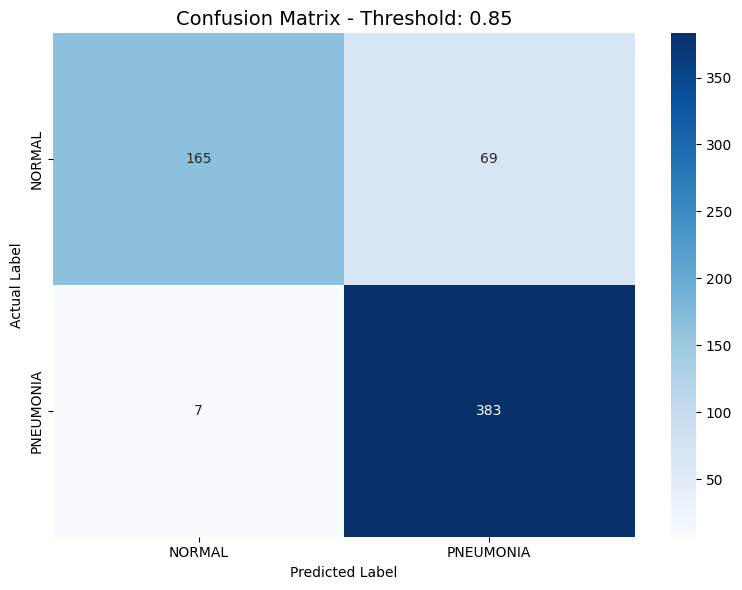


Final Classification Report (threshold=:0.85)
              precision    recall  f1-score   support

      NORMAL       0.96      0.71      0.81       234
   PNEUMONIA       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624

True Negatives  — NORMAL Case correctly identified:     165
False Positives — NORMAL Case wrongly called PNEUMONIA: 69
False Negatives — PNEUMONIA Case missed:                7
True Positives  — PNEUMONIA  Case correctly identified:  383


In [18]:
# Applying Best Threshold for the model

y_pred_best = (y_pred_probs > best_threshold).astype(int).flatten()
cm_best = confusion_matrix(y_true, y_pred_best)
plt.figure(figsize = (8,6))
sns.heatmap(
    cm_best,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = CLASS_NAMES,
    yticklabels = CLASS_NAMES
)
plt.title(f'Confusion Matrix - Threshold: {best_threshold}', fontsize = 14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


print(f"\nFinal Classification Report (threshold=:{best_threshold})")
print(classification_report(
    y_true, y_pred_best, target_names = CLASS_NAMES
))


tn, fp, fn, tp = cm_best.ravel()
print(f"True Negatives  — NORMAL Case correctly identified:     {tn}")
print(f"False Positives — NORMAL Case wrongly called PNEUMONIA: {fp}")
print(f"False Negatives — PNEUMONIA Case missed:                {fn}")
print(f"True Positives  — PNEUMONIA  Case correctly identified:  {tp}")